# Simulação e Modelagem de um Alto-falante

**Autores:** Dante Junqueira Pedrosa, Lucas Souza Mendes, Mateus de Souza Gontijo, Victor Gabriel dos Santos Silva  
**Instituição:** Universidade Federal de Minas Gerais  
**Matrículas:** 2023061401, 2020070558, 2020053530, 2023060804  

---

## I. Introdução

O presente trabalho tem como objetivo o estudo de um modelo multifísico de um alto-falante eletrodinâmico, integrando os subsistemas elétrico, mecânico e acústico do dispositivo por meio de um modelo de parâmetros concentrados. O alto-falante é composto essencialmente por um ímã permanente, uma bobina móvel, um sistema elástico de suspensão e um cone rígido responsável pela radiação sonora.

As físicas envolvidas no funcionamento do dispositivo incluem o problema elastodinâmico do cone, governado pela equação da elastodinâmica e pela relação constitutiva da elasticidade linear isotrópica, o problema eletromagnético, descrito pelas equações de Maxwell no regime quase-estático, e o acoplamento entre as duas físicas por meio da força de Laplace, gerada pela interação entre a corrente na bobina e o campo magnético do ímã. Dada a geometria axissimétrica do dispositivo, é possível reduzir esse sistema de equações diferenciais parciais a um conjunto de equações diferenciais ordinárias.

## II. Modelagem Matemática do Alto-falante

O comportamento elétrico do alto-falante pode ser representado por um circuito equivalente RL associado a uma força contraeletromotriz, resultando na equação obtida pela lei de Kirchhoff das tensões:

$$u(t) = Ri(t) + L \frac{di(t)}{dt} + Bl \frac{dx(t)}{dt}$$

em que $u(t)$ é a tensão aplicada aos terminais da bobina, $i(t)$ a corrente elétrica, $R$ a resistência da bobina, $L$ a indutância e $Bl$ o fator de força, definido pela razão entre a força magnética atuante na bobina e a corrente elétrica.

O comportamento mecânico do sistema é descrito pela segunda lei de Newton aplicada ao conjunto cone-bobina:

$$m \ddot{x} = Bl \cdot i - kx - b \dot{x}$$

em que $m$ é a massa efetiva do cone e da bobina, $k$ a constante elástica da suspensão e $b$ o coeficiente de amortecimento viscoso.

Combinando os dois subsistemas e definindo o vetor de estados $z = (i, x, v)$, com $v = \dot{x}$, o sistema pode ser reescrito na forma de espaço de estados:

$$\dot{z} = Az + Bu, \quad y = Cz$$

com as matrizes dadas por:

$$A = \begin{bmatrix} -\frac{R}{L} & 0 & -\frac{Bl}{L} \\ 0 & 0 & 1 \\ \frac{Bl}{m} & -\frac{k}{m} & -\frac{b}{m} \end{bmatrix}, \quad B = \begin{bmatrix} \frac{1}{L} \\ 0 \\ 0 \end{bmatrix}, \quad C = \begin{bmatrix} 0 & 0 & 1 \end{bmatrix}$$

No modelo linear, o fator de força $Bl$ é considerado constante, igual ao seu valor de repouso $Bl_0$.

**Parâmetros do modelo linear do alto-falante:**

| Parâmetro | Símbolo | Valor |
|---|---|---|
| Massa do cone e da bobina | $m$ | $14,35 \times 10^{-3}$ kg |
| Amortecimento mecânico | $b$ | $0,786$ kg/s |
| Constante elástica da suspensão | $k$ | $1852$ N/m |
| Fator de força em repouso | $Bl_0$ | $4,95$ N/A |
| Indutância da bobina | $L$ | $266 \times 10^{-6}$ H |
| Resistência da bobina | $R$ | $3,3$ $\Omega$ |

A Função de Resposta em Frequência (FRF) do alto-falante a partir da aceleração do cone pode ser estimada por:

$$G(j\omega) = C(j\omega I - A)^{-1}B$$

## III. Metodologia Computacional e Preparação dos Dados

As simulações foram realizadas utilizando a função `solve_ivp` da biblioteca SciPy para a integração numérica do sistema de EDOs com o método RK45. Adotamos condições iniciais nulas: $i(0) = 0$, $x(0) = 0$ e $v(0) = 0$.

O sinal de entrada (áudio) é normalizado e escalado para respeitar a tensão de pico $V_{in} < 2,0$ V, e interpelado linearmente para a integração.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

# =========================================================
# 1) PARÂMETROS DO ALTO-FALANTE (dados no slide 14)
# =========================================================

m  = 14.35e-3   # massa do cone+bobina (kg)
b  = 0.786      # amortecimento mecânico (kg/s)
k  = 1852       # rigidez da suspensão (N/m)
Bl0 = 4.95      # fator de força (N/A) em repouso, usado no modelo linear
L  = 266e-6     # indutância da bobina (H)
R  = 3.3        # resistência da bobina (ohm)

pasta_script = os.getcwd()
pasta_saida = os.path.join(pasta_script, "resultados")
os.makedirs(pasta_saida, exist_ok=True)

# =========================================================
# 2) LER O ÁUDIO GRAVADO E TRANSFORMAR EM Vin(t)
# =========================================================

caminho_audio = os.path.join(pasta_script, "audio.wav")
fs, audio = wavfile.read(caminho_audio)   # fs = taxa de amostragem (Hz)

# Se o áudio for estéreo (2 canais), pega só um canal
if audio.ndim > 1:
    audio = audio[:, 0]

# Converte para float e normaliza entre -1 e 1
audio = audio.astype(np.float64)
audio = audio / np.max(np.abs(audio))

# Escala para satisfazer Vin < 2.0V
V_PICO = 1.8
Vin_amostras = V_PICO * audio

# Vetor de tempo correspondente a cada amostra
t_audio = np.arange(len(Vin_amostras)) / fs

# Cria uma FUNÇÃO u(t) que o integrador pode chamar em qualquer instante
# (o integrador não usa passos fixos, então precisamos poder avaliar
#  Vin em tempos "quebrados" entre as amostras -> interpolação)

u_interp = interp1d(t_audio, Vin_amostras, bounds_error=False, fill_value=0.0)

## IV. Atividade 2: Modelo Não Linear do Fator de Força $Bl(x)$

O fator de força $Bl$ real não é constante, dependendo da posição da bobina em relação ao ímã. Para incorporar esse efeito, foi definida uma função $Bl(x)$:

- Para $|x| \leq x_1$: $Bl$ permanece constante ($Bl_0$).
- Para $|x| \geq x_2$: $Bl$ é nulo.
- Para $x_1 \leq |x| \leq x_2$: O parâmetro decai segundo um polinômio de segunda ordem, com derivada nula em $x_2$.

Os limites foram definidos como 75% e 150% da excursão máxima do cone do modelo linear ($x_{max}$):

$$x_1 = 0,75 x_{max}, \quad x_2 = 1,50 x_{max}$$

A função completa é representada por:

$$
Bl(x) =
\begin{cases} 
Bl_0, & |x| \leq x_1 \\ 
Bl_0 \left( 1 - \frac{|x| - x_1}{x_2 - x_1} \right)^2, & x_1 < |x| < x_2 \\ 
0, & |x| \geq x_2 
\end{cases}
$$

In [3]:
# =========================================================
# 3) MODELO NÃO LINEAR DE Bl(x)  (Atividade 2/3)
# =========================================================

# Excursão máxima do cone no modelo linear (você deve estimar isso
# simulando primeiro o modelo LINEAR e vendo o pico de x(t) obtido).
# Aqui deixo um valor de EXEMPLO - troque pelo valor real que você medir!

x_max_linear = 4.3514e-4 # <--  3e-3 SUBSTITUA pelo pico real de x(t) da simulação linear


x1 = 0.75 * x_max_linear   # até aqui, Bl constante
x2 = 1.50 * x_max_linear   # a partir daqui, Bl = 0

def Bl_de_x(x):
    """
    Fator de força em função da posição do cone.
    |x| <= x1        -> Bl = Bl0 (constante, igual ao modelo linear)
    x1 <= |x| <= x2  -> decaimento polinomial de ordem 2, de Bl0 até 0
    |x| >= x2        -> Bl = 0
    """
    ax = abs(x)
    if ax <= x1:
        return Bl0
    elif ax >= x2:
        return 0.0
    else:
        # polinômio de ordem 2 que vale Bl0 em x1 e 0 em x2,
        # com derivada nula em x2 (transição suave, "encosta" em zero)
        frac = (ax - x1) / (x2 - x1)   # vai de 0 (em x1) a 1 (em x2)
        return Bl0 * (1 - frac)**2


## V. Atividade 1 e 3: Simulação do Sistema

Nesta etapa, integramos o sistema de equações diferenciais. O código permite alternar entre o modelo linear e o não-linear através da variável booleana `NAO_LINEAR`.

*Para visualizar primeiro a Atividade 1, configure `NAO_LINEAR = False`. Para a Atividade 3, altere para `True`.*

In [4]:
# =========================================================
# 4) EQUAÇÕES DE ESTADO  z = [i, x, v]
# =========================================================

NAO_LINEAR = True   # <-- False para rodar a Atividade 1 (modelo linear), True caso contrário
label_modelo = "nao_linear" if NAO_LINEAR else "linear"

def derivadas(t, z):
    i, x, v = z
    u = u_interp(t)  # tensão de entrada no instante t

    Bl = Bl_de_x(x) if NAO_LINEAR else Bl0

    di_dt = -(R/L)*i - (Bl/L)*v + u/L
    dx_dt = v
    dv_dt = (Bl/m)*i - (k/m)*x - (b/m)*v

    return [di_dt, dx_dt, dv_dt]

# =========================================================
# 5) RESOLVER A ODE (condições iniciais nulas)
# =========================================================

z0 = [0.0, 0.0, 0.0]     # i(0)=0, x(0)=0, v(0)=0
t_span = (t_audio[0], t_audio[-1])

# t_eval: pontos onde queremos a solução (mesma taxa do áudio, para facilitar salvar depois)
sol = solve_ivp(derivadas, t_span, z0, t_eval=t_audio, method="RK45", max_step=1/fs)

i_t = sol.y[0]
x_t = sol.y[1]
v_t = sol.y[2]

x_max_linear = np.max(np.abs(x_t))
print(f"Excursão máxima do cone (modelo {label_modelo}): {x_max_linear:.6e} m")

# Aceleração ẍ(t): derivamos a 3ª equação de estado diretamente
# (mais preciso que derivar v_t numericamente)
Bl_vetor = np.array([Bl_de_x(x) if NAO_LINEAR else Bl0 for x in x_t])
a_t = (Bl_vetor/m)*i_t - (k/m)*x_t - (b/m)*v_t   # isso é ẍ(t)

Excursão máxima do cone (modelo nao_linear): 3.937980e-04 m


## VI. Resultados: Análise no Tempo e Espectro

Abaixo plotamos a resposta temporal da tensão de entrada, da corrente, da posição $x(t)$ e da aceleração $\ddot{x}(t)$ do cone. Também geramos o arquivo de áudio de saída correspondente à aceleração gerada pelo sistema.

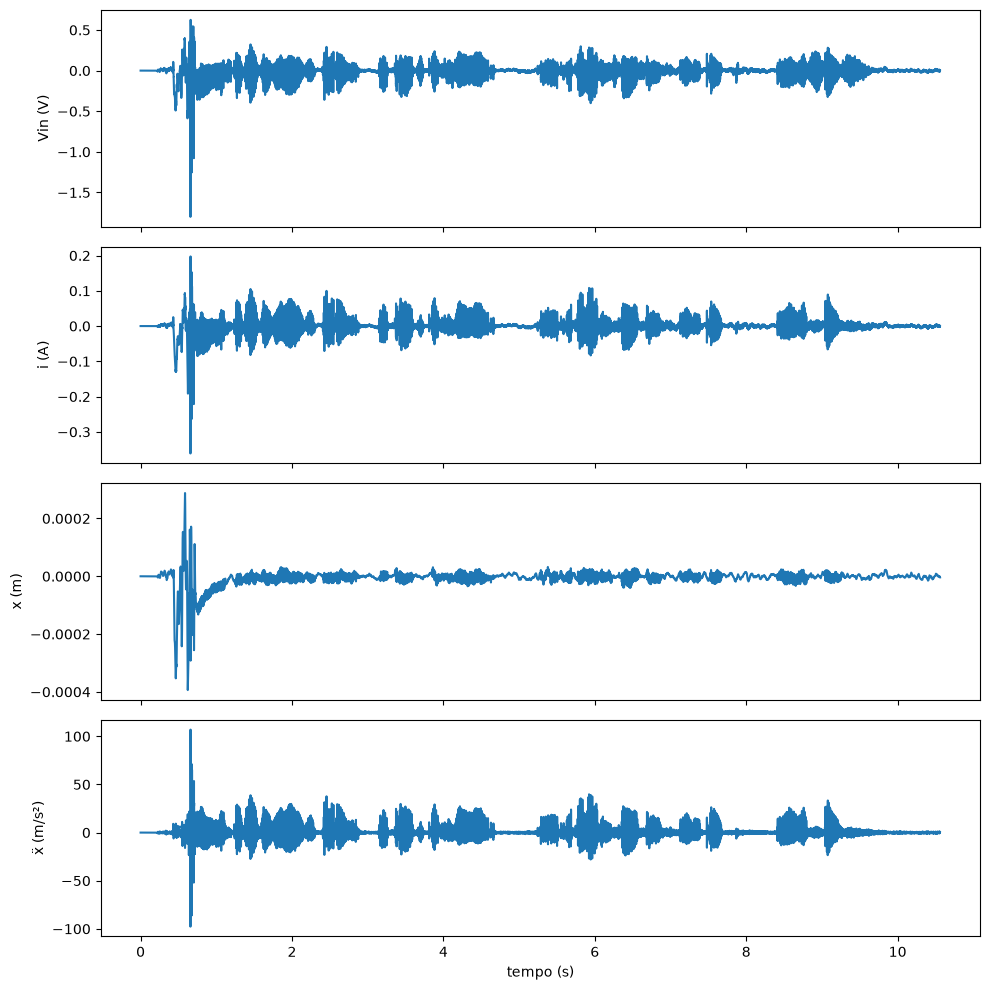

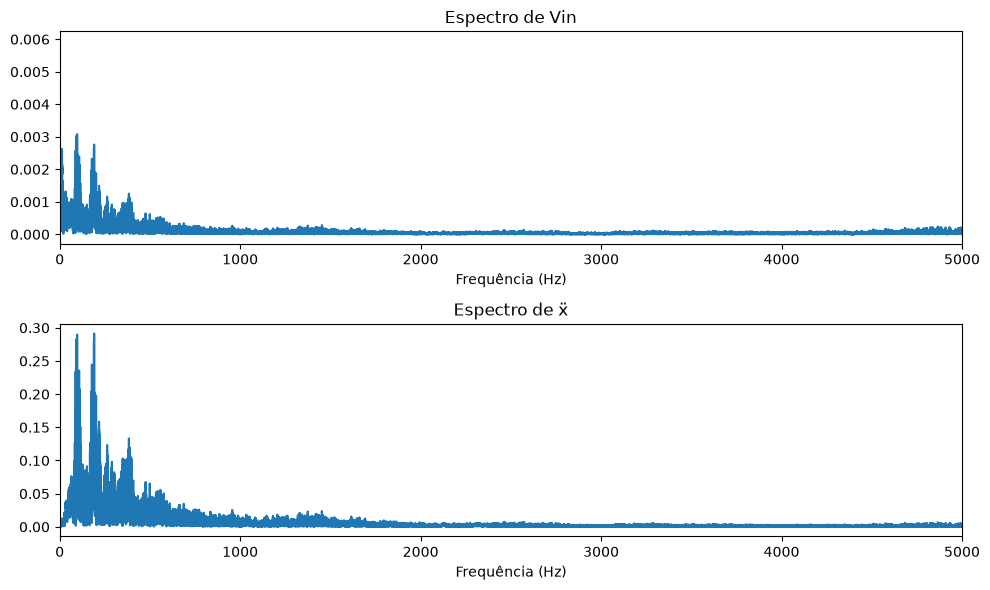

In [5]:

# =========================================================
# 6) GRÁFICOS NO TEMPO
# =========================================================

fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
axs[0].plot(t_audio, Vin_amostras); axs[0].set_ylabel("Vin (V)")
axs[1].plot(t_audio, i_t);          axs[1].set_ylabel("i (A)")
axs[2].plot(t_audio, x_t);          axs[2].set_ylabel("x (m)")
axs[3].plot(t_audio, a_t);          axs[3].set_ylabel("ẍ (m/s²)")
axs[3].set_xlabel("tempo (s)")
plt.tight_layout()
plt.savefig(os.path.join(pasta_saida, f"resposta_temporal_{label_modelo}.png"))

# =========================================================
# 7) ESPECTROS (FFT) DE Vin E ẍ, PARA COMPARAR
# =========================================================

def espectro(sinal, fs):
    N = len(sinal)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    mag = np.abs(np.fft.rfft(sinal)) / N
    return freqs, mag

f_vin, mag_vin = espectro(Vin_amostras, fs)
f_a, mag_a = espectro(a_t, fs)

fig, axs = plt.subplots(2, 1, figsize=(10, 6))
axs[0].plot(f_vin, mag_vin); axs[0].set_title("Espectro de Vin")
axs[0].set_xlim(0, 5000)
axs[1].plot(f_a, mag_a); axs[1].set_title("Espectro de ẍ")
axs[1].set_xlim(0, 5000)
for ax in axs:
    ax.set_xlabel("Frequência (Hz)")
plt.tight_layout()
plt.savefig(os.path.join(pasta_saida, f"espectros_{label_modelo}.png"))

# =========================================================
# 8) SALVAR ẍ(t) COMO ARQUIVO DE ÁUDIO
# =========================================================

#  Normalizar de volta para o formato de áudio (inteiro 16 bits)

a_norm = a_t / np.max(np.abs(a_t))          # normaliza entre -1 e 1
a_int16 = (a_norm * 32767).astype(np.int16) # converte para int16

wavfile.write(os.path.join(pasta_saida, f"tp2-out1_{label_modelo}.wav"), fs, a_int16)

## VII. Função de Resposta em Frequência (FRF)

Calculamos a FRF teórica do sistema linear a partir da função de transferência $G(j\omega)$, sobrepondo-a ao espectro normalizado do sinal de áudio de entrada para identificar se a energia espectral do sinal está contida na banda passante do alto-falante.

Banda passante do alto-falante: 68.5 Hz a 1940.3 Hz (largura: 1871.8 Hz)
Simulação concluída.


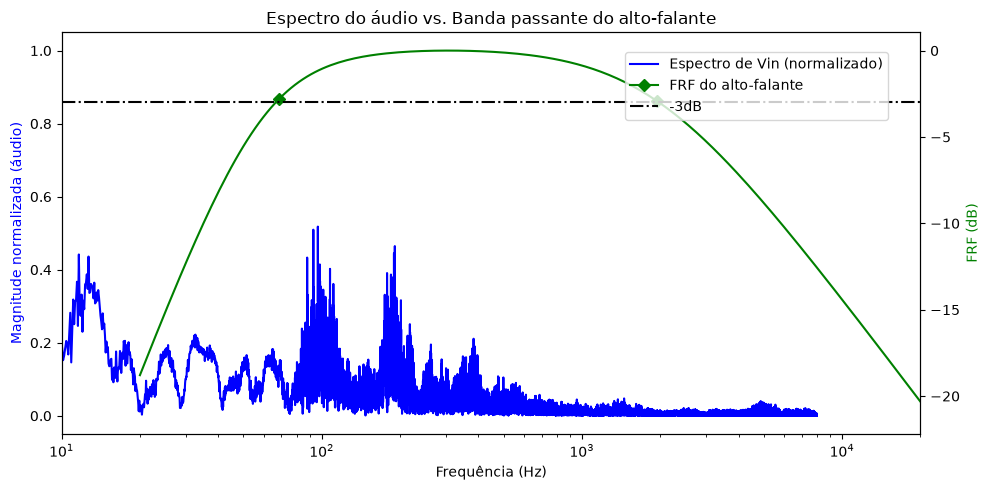

In [6]:
# =========================================================
# 9) FUNÇÃO DE RESPOSTA EM FREQUÊNCIA (FRF) DO SISTEMA LINEAR
# =========================================================
# Aqui calculamos G(jw) = C(jwI - A)^-1 B para uma faixa de frequências,
# usando o modelo LINEAR (Bl constante = Bl0), independente de qual
# modelo você está simulando no tempo (linear ou não linear).
# Isso serve só para visualizar a "banda passante" teórica do alto-falante.

# Faixa de frequência de interesse (mesma do exemplo do professor)
fmin = 20      # Hz
fmax = 22e3    # Hz
npoints = 200
f_frf = np.logspace(np.log10(fmin), np.log10(fmax), npoints)  # escala log
omega = 2 * np.pi * f_frf

# Matrizes de espaço de estados do modelo linear (Bl = Bl0 constante)
A_lin = np.array([[-R/L, 0, -Bl0/L],
                   [0, 0, 1],
                   [Bl0/m, -k/m, -b/m]])
B_lin = np.array([1/L, 0, 0])
C_lin = np.array([0, 0, 1])   # saída = velocidade (v)
I3 = np.eye(3)

# Calcula G(jw) para cada frequência
G = 1j * np.zeros(npoints)
for idx in range(npoints):
    aux = np.linalg.inv(1j*omega[idx]*I3 - A_lin)
    G[idx] = C_lin.dot(aux.dot(B_lin))

# FRF em dB, aproximando a resposta de aceleração: FRF ~ jw*G(jw)
FRF = 20*np.log10(np.abs(1j*omega*G))
FRF = FRF - np.max(FRF)   # normaliza para 0dB no pico (constante de proporcionalidade é desconhecida)

# Encontra a banda passante (-3dB)
Band_indexs = np.flatnonzero(np.where(FRF > -3, 1, 0))
fc_min = f_frf[Band_indexs[0]]
fc_max = f_frf[Band_indexs[-1]]
BW = fc_max - fc_min

print(f"Banda passante do alto-falante: {fc_min:.1f} Hz a {fc_max:.1f} Hz (largura: {BW:.1f} Hz)")

# =========================================================
# 10) PLOTAR FRF JUNTO COM O ESPECTRO DO ÁUDIO DE ENTRADA
# =========================================================
# Reaproveita o espectro de Vin que já calculamos antes (f_vin, mag_vin)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Espectro do áudio (normalizado pelo pico, escala log em x)
ax1.semilogx(f_vin, mag_vin / np.max(mag_vin), 'b', label="Espectro de Vin (normalizado)")
ax1.set_xlabel("Frequência (Hz)")
ax1.set_ylabel("Magnitude normalizada (áudio)", color='b')
ax1.set_xlim(10, 2e4)

# FRF do sistema em um segundo eixo y (está em dB, escala diferente)
ax2 = ax1.twinx()
ax2.semilogx(f_frf, FRF, 'g-D', markevery=[Band_indexs[0], Band_indexs[-1]], label="FRF do alto-falante")
ax2.axhline(-3, color='k', linestyle='-.', label="-3dB")
ax2.set_ylabel("FRF (dB)", color='g')

fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.title("Espectro do áudio vs. Banda passante do alto-falante")
plt.tight_layout()
plt.savefig(os.path.join(pasta_saida, f"frf_vs_espectro_{label_modelo}.png"))

print("Simulação concluída.")


## VIII. Atividade 4: Resposta a um Sinal Senoidal

Com o objetivo de avaliar de forma mais controlada o efeito da não-linearidade do fator de força, simularemos o sistema utilizando um sinal de entrada senoidal puro. As características do sinal foram definidas para atender aos seguintes critérios:
- Frequência dentro da faixa da voz humana: adotaremos $f = 150$ Hz.
- Duração mínima de 20 períodos: adotaremos 30 períodos para garantir a visualização clara do regime permanente.
- Amplitude de 2V de pico (4V pico a pico).

A tensão de entrada é dada por:

$$V_{in}(t) = A \sin(2\pi f t)$$

onde $A = 2,0$ V e $f = 150$ Hz.

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

# =========================================================
# 1) PARÂMETROS DO ALTO-FALANTE (iguais aos anteriores)
# =========================================================

m  = 14.35e-3   # massa do cone+bobina (kg)
b  = 0.786      # amortecimento mecânico (kg/s)
k  = 1852       # rigidez da suspensão (N/m)
Bl0 = 4.95      # fator de força (N/A) em repouso, usado no modelo linear
L  = 266e-6     # indutância da bobina (H)
R  = 3.3        # resistência da bobina (ohm)

pasta_script = os.getcwd()
pasta_saida = os.path.join(pasta_script, "resultados")
os.makedirs(pasta_saida, exist_ok=True)

# =========================================================
# 2) GERANDO O SINAL SENOIDAL DE ENTRADA
# =========================================================

freq_sinal = 150  # Hz - dentro da faixa de voz humana (85-255 Hz)
amplitude = 2.0   # V (pico) -> 4 Vpp, conforme pedido
n_periodos = 30   # mínimo 20 períodos exigido, uso 30 pra folga
fs = 44100        # taxa de amostragem (Hz) - padrão de áudio
duracao = n_periodos / freq_sinal   # duração total do sinal (s)

t_audio = np.arange(0, duracao, 1/fs)
Vin_amostras = amplitude * np.sin(2*np.pi*freq_sinal*t_audio)

u_interp = interp1d(t_audio, Vin_amostras, bounds_error=False, fill_value=0.0)

## IX. Resolução Comparativa: Modelo Linear vs. Não Linear

Para realizar a comparação direta, redefiniremos a função das equações diferenciais para aceitar um argumento booleano (`nao_linear`). Isso nos permite integrar ambos os sistemas sequencialmente utilizando a mesma malha temporal e as mesmas condições iniciais nulas. 

O fator de força não linear utiliza os mesmos limites $x_1$ e $x_2$ calculados na Atividade 2, baseados na excursão do áudio real.

In [9]:
# =========================================================
# 3) MODELO NÃO LINEAR DE Bl(x) - mesmo da Atividade 2/3
# =========================================================

# Usamos o mesmo x_max obtido na Atividade 1 (simulação com áudio real).
# Se quiser, pode recalcular rodando este script primeiro em modo linear
# e pegando o x_max específico para a senoide - mas para manter a
# CONSISTÊNCIA do modelo não linear entre atividades, o ideal é usar o
# mesmo x1/x2 definidos anteriormente.

x_max_linear = 4.3514e-4   # valor obtido na Atividade 1 (modelo linear com áudio real)
x1 = 0.75 * x_max_linear
x2 = 1.50 * x_max_linear

def Bl_de_x(x):
    ax = abs(x)
    if ax <= x1:
        return Bl0
    elif ax >= x2:
        return 0.0
    else:
        frac = (ax - x1) / (x2 - x1)
        return Bl0 * (1 - frac)**2

# =========================================================
# 4) FUNÇÃO DE DERIVADAS (com parâmetro para escolher o modelo)
# =========================================================

def derivadas(t, z, nao_linear):
    i, x, v = z
    u = u_interp(t)
    Bl = Bl_de_x(x) if nao_linear else Bl0

    di_dt = -(R/L)*i - (Bl/L)*v + u/L
    dx_dt = v
    dv_dt = (Bl/m)*i - (k/m)*x - (b/m)*v

    return [di_dt, dx_dt, dv_dt]

# =========================================================
# 5) RESOLVER A ODE PARA OS DOIS MODELOS (linear e não linear)
# =========================================================

z0 = [0.0, 0.0, 0.0]
t_span = (t_audio[0], t_audio[-1])

sol_lin = solve_ivp(derivadas, t_span, z0, args=(False,),
                     t_eval=t_audio, method="RK45", max_step=1/fs)

sol_nlin = solve_ivp(derivadas, t_span, z0, args=(True,),
                      t_eval=t_audio, method="RK45", max_step=1/fs)

# Aceleração para cada modelo
def calc_aceleracao(sol, nao_linear):
    i_t, x_t, v_t = sol.y[0], sol.y[1], sol.y[2]
    Bl_vetor = np.array(
        [Bl_de_x(x) if nao_linear else Bl0 for x in x_t]
    )
    a_t = (Bl_vetor/m)*i_t - (k/m)*x_t - (b/m)*v_t
    return i_t, x_t, v_t, a_t

i_lin, x_lin, v_lin, a_lin = calc_aceleracao(sol_lin, False)
i_nlin, x_nlin, v_nlin, a_nlin = calc_aceleracao(sol_nlin, True)

print(f"Pico de x (linear):     {np.max(np.abs(x_lin)):.6e} m")
print(f"Pico de x (não linear): {np.max(np.abs(x_nlin)):.6e} m")

Pico de x (linear):     4.819996e-04 m
Pico de x (não linear): 5.579656e-04 m


## X. Análise dos Resultados: Transitório e Regime Permanente

Nesta etapa, geramos os gráficos para comparar a posição $x(t)$ e a aceleração $\ddot{x}(t)$ dos dois modelos. 

**Comportamento Físico Observado:**
Diferentemente da resposta ao áudio real, o modelo não linear pode apresentar uma excursão de pico *superior* à do modelo linear durante o regime transitório. Isso ocorre porque o fator de força $Bl$ atua também no amortecimento eletromecânico (através da força contraeletromotriz). Quando a excursão ultrapassa $x_1$, a redução de $Bl$ diminui esse amortecimento, permitindo uma oscilação transitória maior.

Após o regime transitório inicial, a amplitude de oscilação do sistema se estabiliza. Plotaremos um *zoom* nos últimos 3 períodos para avaliar o **Regime Permanente**.

Atividade 4 concluída.


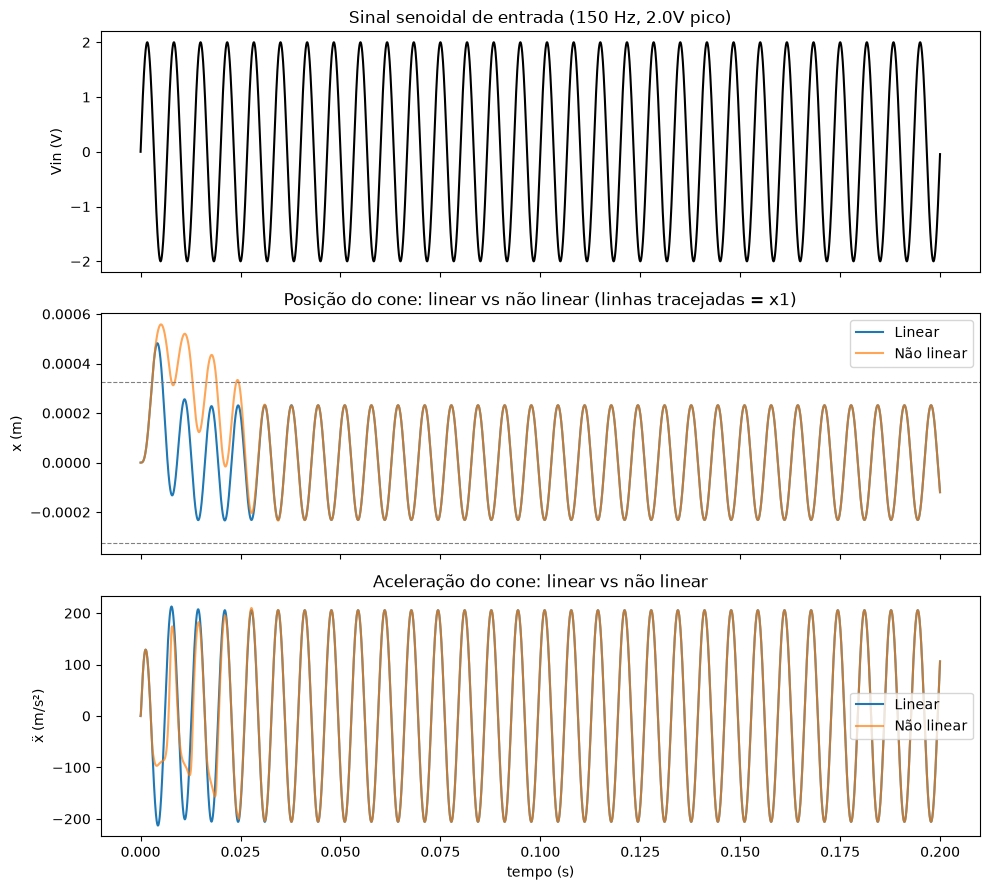

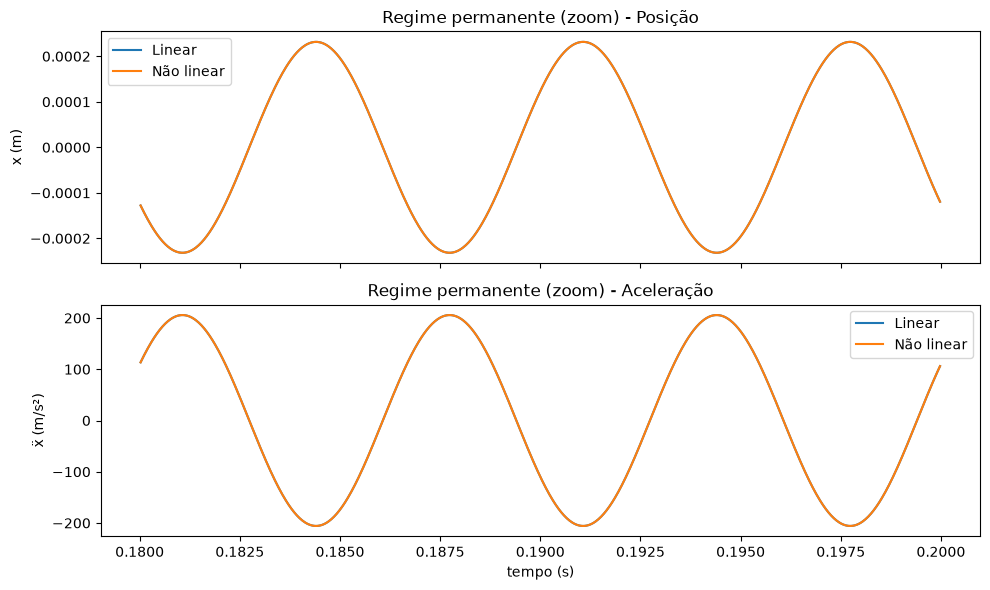

In [10]:
# =========================================================
# 6) COMPARAÇÃO GRÁFICA: LINEAR x NÃO LINEAR
# =========================================================

fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axs[0].plot(t_audio, Vin_amostras, 'k')
axs[0].set_ylabel("Vin (V)")
axs[0].set_title(f"Sinal senoidal de entrada ({freq_sinal} Hz, {amplitude}V pico)")

axs[1].plot(t_audio, x_lin, label="Linear")
axs[1].plot(t_audio, x_nlin, label="Não linear", alpha=0.7)
axs[1].axhline(x1, color='gray', linestyle='--', linewidth=0.8)
axs[1].axhline(-x1, color='gray', linestyle='--', linewidth=0.8)
axs[1].set_ylabel("x (m)")
axs[1].legend()
axs[1].set_title("Posição do cone: linear vs não linear (linhas tracejadas = x1)")

axs[2].plot(t_audio, a_lin, label="Linear")
axs[2].plot(t_audio, a_nlin, label="Não linear", alpha=0.7)
axs[2].set_ylabel("ẍ (m/s²)")
axs[2].set_xlabel("tempo (s)")
axs[2].legend()
axs[2].set_title("Aceleração do cone: linear vs não linear")

plt.tight_layout()
plt.savefig(os.path.join(pasta_saida, "atividade4_comparacao_senoide.png"))

# =========================================================
# 7) ZOOM NO REGIME PERMANENTE (últimos períodos, sem transitório)
# =========================================================

# O regime transitório ocorre nos primeiros períodos, até o sistema
# "assentar". Aqui damos zoom nos últimos períodos para ver o regime
# permanente já estabilizado.

n_periodos_zoom = 3
t_zoom_final = duracao
t_zoom_inicio = t_zoom_final - n_periodos_zoom/freq_sinal
mask = (t_audio >= t_zoom_inicio) & (t_audio <= t_zoom_final)

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(t_audio[mask], x_lin[mask], label="Linear")
axs[0].plot(t_audio[mask], x_nlin[mask], label="Não linear")
axs[0].set_ylabel("x (m)")
axs[0].legend()
axs[0].set_title("Regime permanente (zoom) - Posição")

axs[1].plot(t_audio[mask], a_lin[mask], label="Linear")
axs[1].plot(t_audio[mask], a_nlin[mask], label="Não linear")
axs[1].set_ylabel("ẍ (m/s²)")
axs[1].set_xlabel("tempo (s)")
axs[1].legend()
axs[1].set_title("Regime permanente (zoom) - Aceleração")

plt.tight_layout()
plt.savefig(os.path.join(pasta_saida, "atividade4_zoom_regime_permanente.png"))

print("Atividade 4 concluída.")

## XI. Conclusão

A partir das simulações realizadas com o sinal de áudio real, verificou-se que o modelo linear é capaz de reproduzir adequadamente a resposta do sistema quando a excursão do cone permanece dentro de limites moderados. A análise espectral confirmou que a maior parte da energia do sinal de entrada está contida na banda passante teórica do sistema (68,5 Hz a 1940,3 Hz).

A introdução da não linearidade do fator de força $Bl(x)$, modelada por um decaimento polinomial de segunda ordem, mostrou-se relevante em condições de excitação mais intensas (como a senoide de 4Vpp). Nessas condições, constatou-se que a variação do fator de força afeta não apenas a força motriz, mas também o amortecimento eletromecânico, resultando em excursões transitórias maiores do que as previstas no regime linear. 

Em regime permanente, contudo, observou-se que para os níveis de tensão adotados a amplitude estabiliza em $|x| < x_1$. Consequentemente, o fator de força retorna à sua região de operação constante, fazendo com que o comportamento dos modelos linear e não linear se tornem equivalentes após o fim do transitório.

---

### Referências
1. R. Adriano, *Modelagem e Simulação Multifísica – Aula 06: O Problema do Alto-falante*, Notas de aula, Universidade Federal de Minas Gerais, 2026.
2. N. Ida e J. P. A. Bastos, *Electromagnetics and Calculation of Fields*, 2ª ed., Springer, New York, 1997.
3. J. P. A. Bastos, *Eletromagnetismo para Engenharia: Estática e Quase-Estática*, Editora UFSC, Florianópolis, 2004.
4. M. N. O. Sadiku, *Numerical Techniques in Electromagnetics*, 2ª ed., CRC Press, Boca Raton, 2001.
5. P. Brunet, *Nonlinear System Identification and Control of Loudspeakers*, Tese de Doutorado, Northeastern University, 2014.
6. Wikipedia, *Loudspeaker*.